In [1]:
# import packages
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import cooltools
import cooler
import re

from matplotlib.ticker import EngFormatter
from matplotlib.ticker import MultipleLocator, FormatStrFormatter
from matplotlib.ticker import FuncFormatter

%cd /home/varshini/uc_analyses/
import utils
%cd /home/varshini/LoopCall_Analysis_Scripts

bp_formatter = EngFormatter('b')

        
from matplotlib.colors import LogNorm
import cooltools.lib.plotting
from mpl_toolkits.axes_grid1 import make_axes_locatable


/home/varshini/uc_analyses
/home/varshini/LoopCall_Analysis_Scripts


In [2]:
plt.rcParams.update({
    "text.usetex": False})
plt.rcParams['svg.fonttype'] = 'none'
plt.rc('pdf',fonttype = 42)
plt.rcParams["ps.useafm"] = True

In [3]:
def get_coords(locus_str):
    m = re.search(r'(chr\d+):(\d+)-(\d+)', locus_str)
    chrom = m.group(1)
    start_coord = int(m.group(2))
    end_coord = int(m.group(3))

    return chrom, start_coord, end_coord

In [4]:

def sci_notation(num, decimal_digits=1, precision=None, exponent=None):
    return r"$10^{{{0:d}}}$".format(num)

@FuncFormatter
def my_formatter(x, pos):
     return "{}".format(10^{x})
#cbar_format_2 = r"10^{{{0:d}}}".format


def plotter(region):
    
    f, axs = plt.subplots(
    figsize=(20, 20),
    nrows=1,
    ncols=1,
    sharex=True,
    sharey=False
    )
    
    chrom, start, end = get_coords(region)
    extents = (start, end, end, start)
    norm_balanced = LogNorm(vmax=0.1) # the vmax is tunable 
    cbar_format = FormatStrFormatter('%.2f')

    mat = clr.matrix(balance=True).fetch(region)
    ax = axs
    ax.set_title('Test')
    im2 = ax.matshow(
        mat,
        cmap='fall',
        extent=extents, 
        norm=norm_balanced
    );
    cb = plt.colorbar(im2, ax=ax, fraction=0.046, pad=0.04, label='contact frequency', ticks = [10e-4, 10e-3, 10e-2], location='left');
    
    return f



def format_ticks(ax, x=True, y=False, rotate=True):
    if y:
        ax.yaxis.set_major_formatter(bp_formatter)
    if x:
        ax.xaxis.set_major_formatter(bp_formatter)
        ax.xaxis.tick_bottom()
    if rotate:
        ax.tick_params(axis='x',rotation=45)
        

In [26]:
# loop_dict defines the max intensities of the loops
# coord dict defines the anchors that are paired 
def plot_loops_region(region, loops,  res, coord_dict=None, loop_dict=None, size_kb=200, norm=LogNorm(),
                     gridspec = {'width_ratios': [1, 1, 1]}, size_kb2 = None, vmin=0.0001, vmax=0.01, sd=None):
    
    chrom, start_coord, end_coord = get_coords(region)
    
    #for pair, thresh in loops.items():
    for _, loop_row in loops.iterrows():
        print(loop_row)
        
        f, axs = plt.subplots(
        figsize=(12, 24),
        nrows=1,
        ncols=3,
        sharex=True,
        sharey=False,
        gridspec_kw=gridspec
        )
        
        for phase in range(3):
            print(phase)
            curr_cooler = COOLERS[phase]
            mat = curr_cooler.matrix(balance=True).fetch(region)

#             p1, p2 = pair.split('_')
#             c1 = coords[p1] 
#             c2 = coords[p2]
            
            c1 = loop_row['start1']+2500
            c2 = loop_row['start2']+2500
            
            # subset the matrix in pix
            c1_pix = (c1-start_coord) // res 
            c2_pix = (c2-start_coord) // res 

            # convert the window to pixels
            window_pix = (size_kb*1000)//res
            
            if size_kb2 is None: 
                sub_mat = mat[c1_pix-window_pix:c1_pix+window_pix, c2_pix-window_pix:c2_pix+window_pix]
                extents = [c1_pix-window_pix,c1_pix+window_pix,c2_pix-window_pix,c2_pix+window_pix]
            else:
              # plot
                window_pix2 = (size_kb2*1000)//res

                sub_mat = mat[c1_pix-window_pix:c1_pix+window_pix, c2_pix-window_pix2:c2_pix+window_pix2]
                #extents = [c1_pix-window_pix,c1_pix+window_pix,c2_pix-window_pix2,c2_pix+window_pix2]
            ax = axs[phase]
            
            #ax.set_title(f"Phase {phase}")
            if norm is None:
                im2 = ax.matshow(
                    sub_mat,
                    cmap='fall',
                    vmin=vmin, 
                    vmax=vmax,
                    aspect='equal'
                );
            else:
                im2 = ax.matshow(
                    sub_mat,
                    cmap='fall',
                    norm=LogNorm(vmin=vmin, vmax=vmax),
                    aspect='equal'
                );


#         for axes in axs:
#             axes.set_aspect(1)
        ax_divider = make_axes_locatable(ax)
        cax = ax_divider.append_axes("right", size="5%", pad=0.1)
        cbar = plt.colorbar(
            im2, 
            cax=cax,
            ticks=LogLocator(base=10.0, subs=(1.0,)),  # Ticks strictly at powers of 10
            format=LogFormatterMathtext(base=10.0)      # Renders clean LaTeX superscripts like 10³
        )

        for ax in axs.ravel():
            ax.set_xticks([])
            ax.set_yticks([])

        
#         cax = ax_divider.append_axes("right", size=0.09, pad=0.2)
#         #cb = plt.colorbar(im2, cax=cax, ticks = [0, thresh], location='right');
#         cb = plt.colorbar()
        #fileName = f"phasePlot_{pair}.svg"
        if sd is not None:
            plt.savefig(sd)
        else:
            plt.show()
        
        #plt.savefig(saveDir + fileName, dpi=1200)
        
def plot_region_bounds(region, bounds,  res, coord_dict=None, loop_dict=None, size_kb=200, norm=LogNorm(),
                     gridspec = {'width_ratios': [1, 1, 1]}, size_kb2 = None, vmin=0.0001, vmax=0.01, sd=None):
    
    chrom, start_coord, end_coord = get_coords(region)
    
    #for pair, thresh in loops.items():
    for _, bound_row in loops.iterrows():
        print(bound_row)
        
        f, axs = plt.subplots(
        figsize=(12, 24),
        nrows=1,
        ncols=3,
        sharex=True,
        sharey=False,
        gridspec_kw=gridspec
        )
        
        for phase in range(3):
            print(phase)
            curr_cooler = COOLERS[phase]
            mat = curr_cooler.matrix(balance=True).fetch(region)

            
            c1_start = bound_row['start1']
            c1_end = bound_row['end1']
            c2_start = bound_row['start2']
            c2_end = bound_row['end2']
            
            # subset the matrix in pix
            c1_start_pix = (c1_start-start_coord) // res 
            c1_end_pix = (c1_end-start_coord) // res 
            c2_start_pix = (c1_start-start_coord) // res 
            c2_end_pix = (c2_end-start_coord) // res 

            sub_mat = mat[c1_start_pix:c1_end_pix, c2_start_pix:c2_end_pix]
            ax = axs[phase]
            
            #ax.set_title(f"Phase {phase}")
            if norm is None:
                im2 = ax.matshow(
                    sub_mat,
                    cmap='fall',
                    vmin=vmin, 
                    vmax=vmax,
                    aspect='equal'
                );
            else:
                im2 = ax.matshow(
                    sub_mat,
                    cmap='fall',
                    norm=LogNorm(vmin=vmin, vmax=vmax),
                    aspect='equal'
                );

#         for axes in axs:
#             axes.set_aspect(1)

        for ax in axs.ravel():
            ax.set_xticks([])
            ax.set_yticks([])

        ax_divider = make_axes_locatable(ax)
        if sd is not None:
            plt.savefig(sd)
        else:
            plt.show()
        
        #plt.savefig(saveDir + fileName, dpi=1200)

##  TIME COURSE PLOTTING

In [6]:
coords = {'Casgevy':60495265, 'Casgevy2':60500565, 'BCL11A':60553498, 'BCL2':60560498, 'REL':60881494, 'PAPOLG':60756229, 'LNC':60335016, 'ING1':60678000}
loops = {'Casgevy_BCL11A':0.01, 'Casgevy2_LNC':0.01,'Casgevy_REL':0.002, 'BCL11A_REL':0.0025,'BCL11A_PAPOLG':0.0025, 'BCL11A_ING1':0.01}
loops = {'Casgevy_BCL11A':0.01, 'Casgevy2_LNC':0.01, 'BCL11A_REL':0.0025,'BCL2_ING1':0.01}


In [7]:
# rcmc
resolution = 2000
phases_rcmc = {1: 'P1', 2:'P2', 3:'P3'}
rcmc_fnames = [f'/mnt/coldstorage/Varshmallow/Blood_RCMC/RCMC_Blood_{phases_rcmc[phase]}_allCap_hg38.merged.50.mcool' for phase in phases_rcmc]
COOLERS = [utils.get_clr(clr_name, resolution) for clr_name in rcmc_fnames]

In [8]:
# load coolers 
resolution = 2000
phases = ['Phase1_', 'Phase2_dedup',  'Phase3_dedup']
phases_microc = {1: 'Phase1_', 2:'Phase2_dedup',3:'Phase3_dedup'}

cooler_path = '/mnt/coldstorage/Varshmallow/Adipose_Blood_Merged/sankaran'
cooler_names = [os.path.join(cooler_path, f"Sankaran_{p}merged.250.mcool") for p in phases]
COOLERS = [utils.get_clr(cooler_names[phase_index], resolution) for phase_index in range(3)]

In [9]:
savedir='/mnt/md0/varshini/Analysis/Blood/figs_v2/fig1'

In [10]:
cooler_names

['/mnt/coldstorage/Varshmallow/Adipose_Blood_Merged/sankaran/Sankaran_Phase1_merged.250.mcool',
 '/mnt/coldstorage/Varshmallow/Adipose_Blood_Merged/sankaran/Sankaran_Phase2_dedupmerged.250.mcool',
 '/mnt/coldstorage/Varshmallow/Adipose_Blood_Merged/sankaran/Sankaran_Phase3_dedupmerged.250.mcool']

In [11]:
loopcalls = pd.read_csv("/mnt/md0/varshini/Analysis/Blood/complete_analyses/loops_anchors/merged_calls_125kb_q0.01_classes_new.txt", 
                       sep="\t").rename({'seqnames1':'chr1'}, axis=1)

In [12]:
loopcalls

,chr1,start1,end1,annotation1,seqnames2,start2,end2,annotation2,pair
0,chr1,5990001,5995000,P,chr1,6197001,6202000,P,P-P
1,chr1,5991001,5996000,P,chr1,6024001,6029000,P,P-P
2,chr1,6039001,6044000,P,chr1,6242001,6247000,P,P-P
3,chr1,6050001,6055000,Null,chr1,6242001,6247000,P,P-Null
4,chr1,6107001,6112000,CTCF,chr1,6169001,6174000,Null,CTCF-Null
...,...,...,...,...,...,...,...,...,...
63724,chrX,152950001,152955000,Null,chrX,154310001,154315000,Null,Null-Null
63725,chrX,153545001,153550000,Null,chrX,154535001,154540000,P,P-Null
63726,chrX,153740001,153745000,Null,chrX,154540001,154545000,P,P-Null
63727,chrX,155640001,155645000,Null,chrX,155955001,155960000,Null,Null-Null


In [13]:
coords = {'Casgevy':60495265, 'Casgevy2':60500565, 'BCL11A':60553498, 'BCL2':60560498, 'REL':60881494, 'PAPOLG':60756229, 'LNC':60335016, 'ING1':60678000}
loops = {'Casgevy_BCL11A':0.01, 'Casgevy2_LNC':0.01,'Casgevy_REL':0.002, 'BCL11A_REL':0.0025,'BCL11A_PAPOLG':0.0025, 'BCL11A_ING1':0.01}
loops = {'Casgevy_BCL11A':0.01, 'Casgevy2_LNC':0.01, 'BCL11A_REL':0.0025,'BCL2_ING1':0.01}
regions = {
        'BCL11A':'chr2:59964475-60946280',
        'BCL11A_full':'chr2:58164475-60976280',
        'loop_appear': 'chr5:173570169-174026097 ',
        'loop_disappear': 'chr7:11365292-12545212',
        'cre_vs_ctcf':"chr17:80402000-81073000",
        'cre_ctcf_2':'chr7:139026000-139387000'
}

In [14]:
reg = 'BCL11A_full'
chrom, st, ed = get_coords(regions[reg])
loopcalls_sub = loopcalls[(loopcalls['chr1']==chrom) & 
                         (loopcalls['start1'] > st) &
                         (loopcalls['end2'] < ed)].reset_index(drop=True)

In [15]:
loopcalls_sub

,chr1,start1,end1,annotation1,seqnames2,start2,end2,annotation2,pair
0,chr2,58569001,58574000,CTCF,chr2,58679001,58684000,Null,CTCF-Null
1,chr2,58569001,58574000,CTCF,chr2,58757001,58762000,E,E-CTCF
2,chr2,58613001,58618000,E,chr2,58728001,58733000,Null,E-Null
3,chr2,58760001,58765000,CTCF,chr2,59179001,59184000,CTCF,CTCF-CTCF
4,chr2,59023001,59028000,CTCF,chr2,59177001,59182000,Null,CTCF-Null
5,chr2,59032001,59037000,E,chr2,59167001,59172000,E,E-E
6,chr2,59032001,59037000,E,chr2,59082001,59087000,E,E-E
7,chr2,59081001,59086000,E,chr2,59175001,59180000,CTCF,E-CTCF
8,chr2,59081001,59086000,E,chr2,59179001,59184000,CTCF,E-CTCF
9,chr2,58760001,58765000,CTCF,chr2,60548001,60553000,P,P-CTCF


chr1               chr2
start1         60494501
end1           60499500
annotation1           E
seqnames2          chr2
start2         60550501
end2           60555500
annotation2           P
pair                E-P
Name: 37, dtype: object
0
1
2


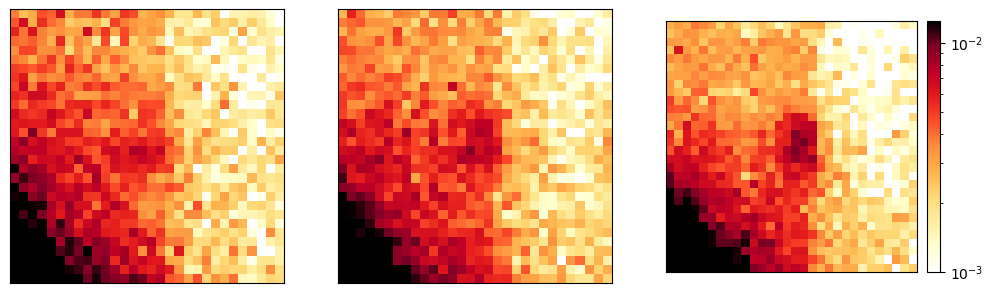

In [48]:
resolution=2000
COOLERS = [utils.get_clr(rcmc_fnames[phase_index], resolution) for phase_index in range(3)]

sd = os.path.join(savedir, "casgevy_rcmc.svg")
savedir=None

inset_1 = loopcalls_sub.iloc[37:38,:]
plot_loops_region(regions['BCL11A_full'],inset_1, resolution, size_kb=30, size_kb2=30, 
                  vmin=0.001, vmax=0.0125, sd=sd)

In [30]:
resolution = 2000
phases = ['Phase1_', 'Phase2_dedup',  'Phase3_dedup']
phases_microc = {1: 'Phase1_', 2:'Phase2_dedup',3:'Phase3_dedup'}

cooler_path = '/mnt/coldstorage/Varshmallow/Adipose_Blood_Merged/sankaran'
cooler_names = [os.path.join(cooler_path, f"Sankaran_{p}merged.250.mcool") for p in phases]
COOLERS = [utils.get_clr(cooler_names[phase_index], resolution) for phase_index in range(3)]

chr1               chr2
start1         59176501
end1           59181500
annotation1        CTCF
seqnames2          chr2
start2         60552501
end2           60557500
annotation2           P
pair             P-CTCF
Name: 31, dtype: object
0
1
2


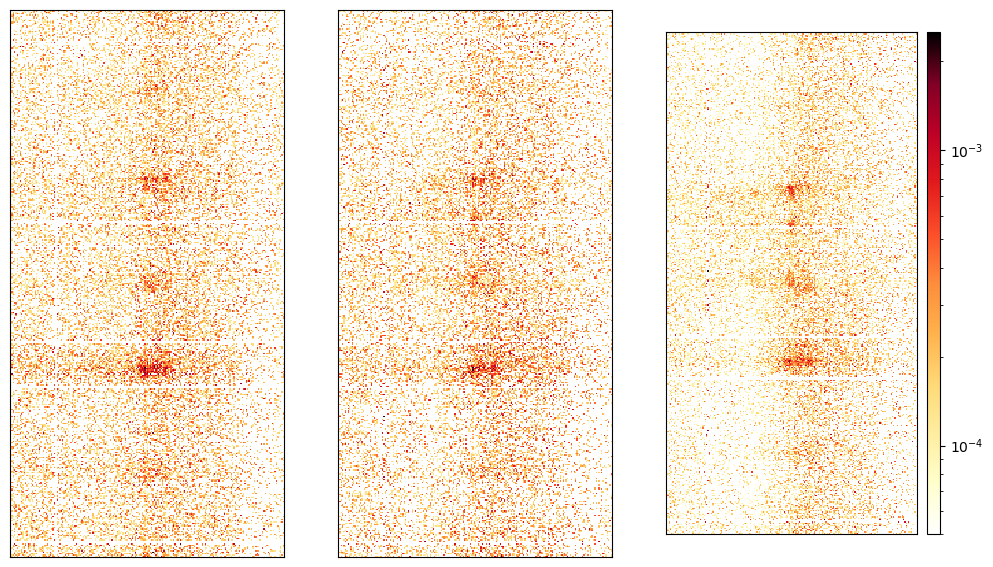

In [31]:
inset_1 = loopcalls_sub.iloc[31:32,:]
plot_loops_region(regions['BCL11A_full'],inset_1, resolution, size_kb=400, size_kb2=200, 
                  vmin=0.00005, vmax=0.0025, sd=None)

chr1          chr2
start1    59100000
end1      59100000
chr2          chr2
start2    59100000
end2      59100000
Name: 0, dtype: object
0
1
2


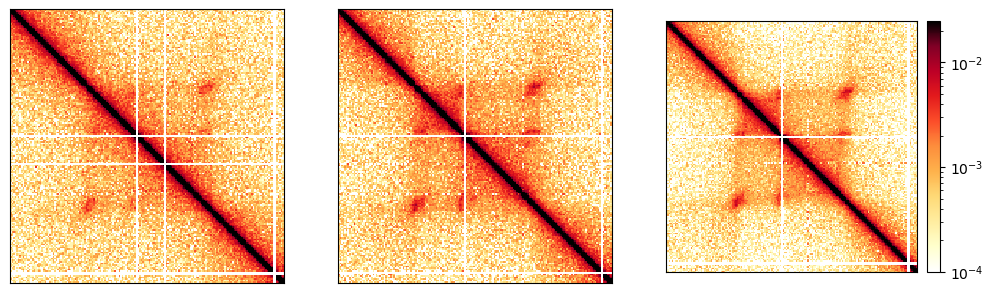

In [47]:
inset_2 = pd.DataFrame({'chr1':['chr2'],'start1':[59100000],'end1':[59100000],
                         'chr2':['chr2'],'start2':[59100000],'end2':[59100000]})
plot_loops_region(regions['BCL11A_full'],inset_2, resolution, size_kb=175, size_kb2=175, 
                  vmin=0.0001, vmax=0.025, sd=os.path.join(savedir, "bcl11a_inset_2.svg"))

In [43]:
reg = 'cre_vs_ctcf'
chrom, st, ed = get_coords(regions[reg])
loopcalls_sub = loopcalls[(loopcalls['chr1']==chrom) & 
                         (loopcalls['start1'] > st) &
                         (loopcalls['end2'] < ed)].reset_index(drop=True)

chr1          chr8
start1    77800000
end1      77800000
chr2          chr8
start2    78250000
end2      78250000
Name: 0, dtype: object
0
1
2


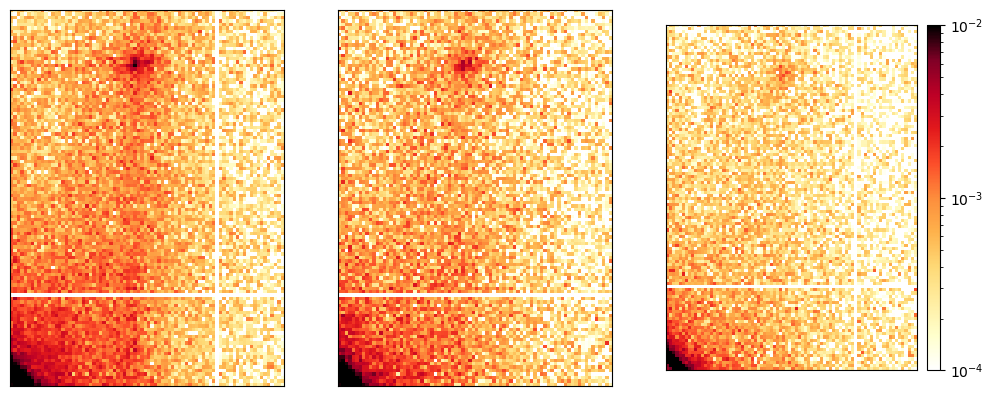

In [28]:
resolution=5000
COOLERS = [utils.get_clr(cooler_names[phase_index], resolution) for phase_index in range(3)]
sd=os.path.join(savedir, "boundary_insets.svg")

boundary = pd.DataFrame({'chr1':['chr8'],'start1':[77_800_000],'end1':[77_800_000],
                         'chr2':['chr8'],'start2':[78_250_000],'end2':[78_250_000]})
# os.path.join(savedir, 'boundary_disappear_insets.svg')
print(f"inset: {boundary['start1']-600_000}-{boundary['start1']+600_000} & 
      {boundary['start2']-600_000}-{boundary['start2']+600_000}")

plot_loops_region("chr8:75561811-79081548",boundary, resolution, size_kb=275, size_kb2=200, 
                  vmin=0.0001, vmax=0.01, sd=None)

In [24]:
from matplotlib.ticker import LogLocator, LogFormatterMathtext


chr1           chr5
start1    149750000
end1      149750000
chr2           chr5
start2    151250000
end2      151250000
Name: 0, dtype: object
0
1
2


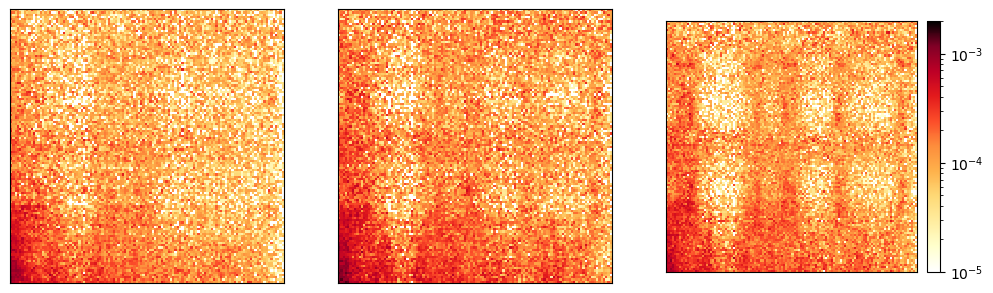

In [27]:
resolution=10000
sd=os.path.join(savedir, "compt_ex_1_insets.svg")

COOLERS = [utils.get_clr(cooler_names[phase_index], resolution) for phase_index in range(3)]

compt = pd.DataFrame({'chr1':['chr5'],'start1':[149_750_000],'end1':[149_750_000],
                         'chr2':['chr5'],'start2':[151_250_000],'end2':[151_250_000]})

print(f"inset: {compt['start1']-600_000}-{compt['start1']+600_000} & 
      {compt['start2']-600_000}-{compt['start2']+600_000}")
plot_loops_region("chr5:149023111-152003168",compt, resolution, size_kb=600, size_kb2=600, 
                  vmin=0.00001, vmax=0.002, sd=None)

In [56]:
savedir = '/mnt/md0/varshini/Analysis/Blood/figs_v2/fig1'

chr1         chr19
start1    49455000
end1      49455000
chr2         chr19
start2    49700000
end2      49700000
Name: 0, dtype: object
0
1
2


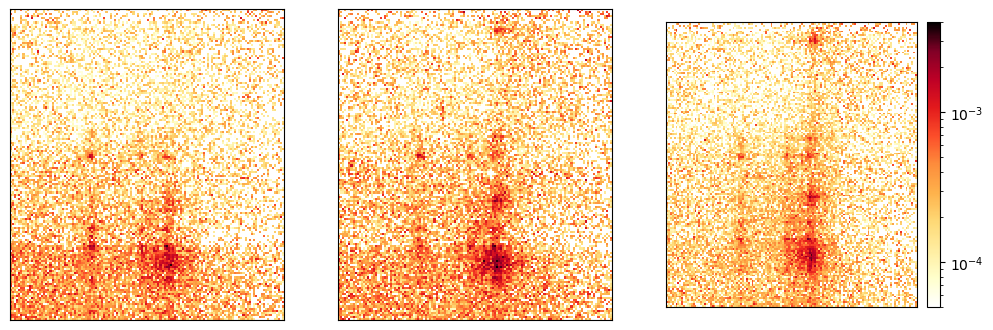

In [57]:
resolution=1000
sd=os.path.join(savedir, "changing_cre_insets.svg")

COOLERS = [utils.get_clr(cooler_names[phase_index], resolution) for phase_index in range(3)]


cre_changing = pd.DataFrame({'chr1':['chr19'],'start1':[49_455_000],'end1':[49_455_000],
                         'chr2':['chr19'],'start2':[49_700_000],'end2':[49_700_000]})
plot_loops_region("chr19:49314500-49733500'",cre_changing, resolution, size_kb=75, size_kb2=100, 
                  vmin=0.00005, vmax=0.004, sd=sd)



chr1         chr19
start1    49480000
end1      49480000
chr2         chr19
start2    49600000
end2      49600000
Name: 0, dtype: object
0
1
2


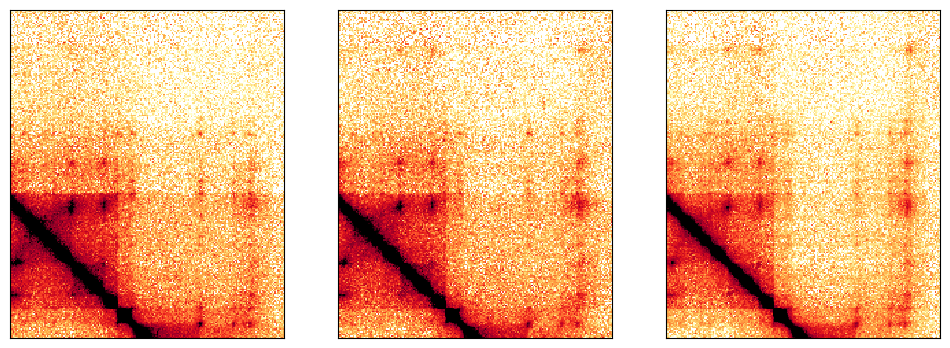

In [126]:
resolution=1000
COOLERS = [utils.get_clr(cooler_names[phase_index], resolution) for phase_index in range(3)]


cre_changing = pd.DataFrame({'chr1':['chr19'],'start1':[49_480_000],'end1':[49_480_000],
                         'chr2':['chr19'],'start2':[49_600_000],'end2':[49_600_000]})
plot_loops_region("chr19:49314500-49733500'",cre_changing, resolution, size_kb=120, size_kb2=100, 
                  vmin=0.00005, vmax=0.008, sd=os.path.join(savedir, "changing_cre_insets.svg"))

#sd=os.path.join(savedir, "changing_cre_insets.svg")


chr1         chr11
start1    16190000
end1      16190000
chr2         chr11
start2    16605000
end2      16605000
Name: 0, dtype: object
0
1
2
chr1         chr11
start1    16378000
end1      16378000
chr2         chr11
start2    16605000
end2      16605000
Name: 1, dtype: object
0
1
2


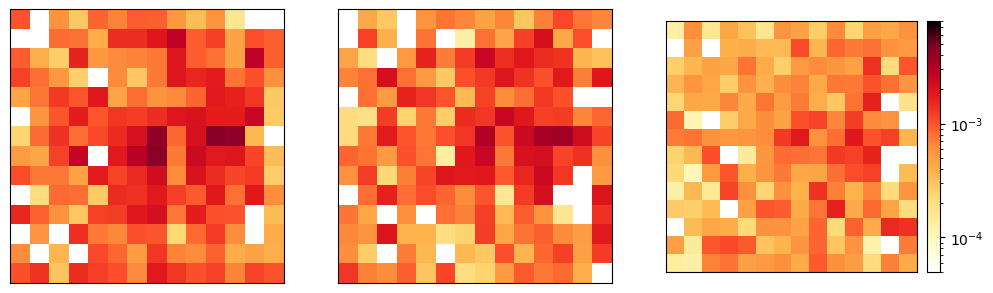

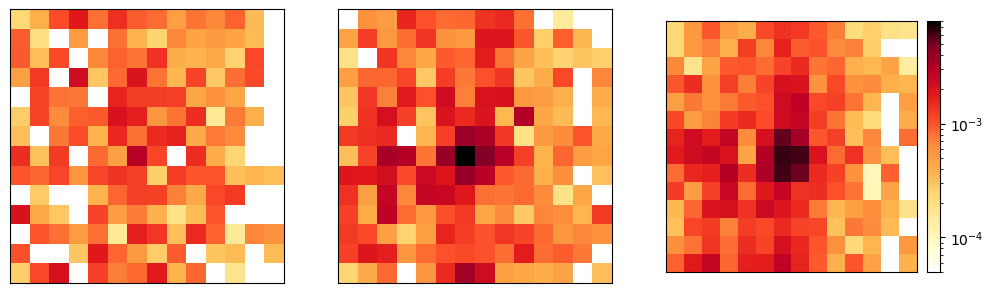

In [52]:
resolution=2000
COOLERS = [utils.get_clr(cooler_names[phase_index], resolution) for phase_index in range(3)]
savedir="/mnt/md0/varshini/Analysis/Blood/figs_v2/fig2"

sox6 = pd.DataFrame({'chr1':['chr11', 'chr11'],'start1':[16_190_000, 16_378_000],'end1':[16_190_000, 16_378_000],
                         'chr2':['chr11','chr11'],'start2':[16_605_000,16_605_000],'end2':[16_605_000,16_605_000]})
plot_loops_region("chr11:16066449-16709591",sox6, resolution, size_kb=15, size_kb2=15, 
                  vmin=0.00005, vmax=0.008, sd=os.path.join(savedir, 'sox6_insets.svg'))

## Supplement

chr1           chr5
start1    173750000
end1      173750000
chr2           chr5
start2    173850000
end2      173850000
Name: 0, dtype: object
0
1
2


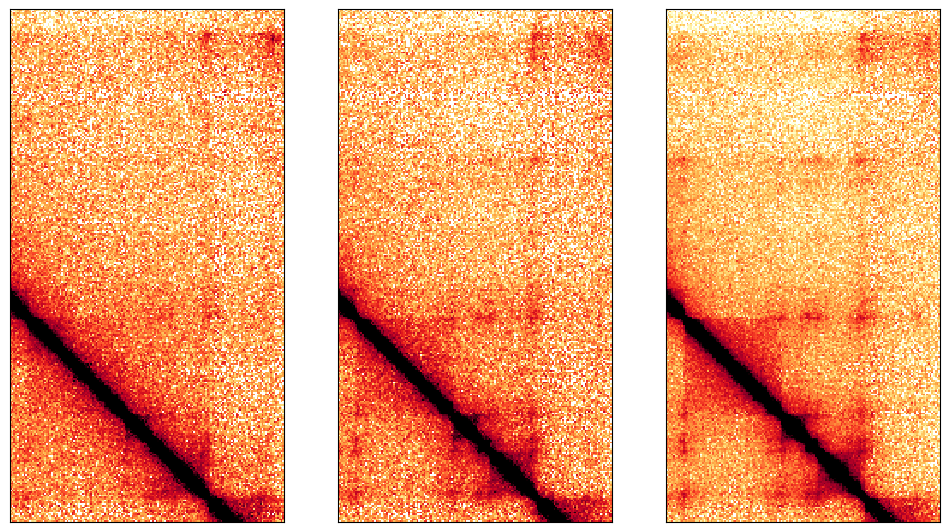

In [26]:
cpeb = pd.DataFrame({'chr1':['chr5'],'start1':[173_750_000],'end1':[173_750_000],
                         'chr2':['chr5'],'start2':[173_850_000],'end2':[173_850_000]})
plot_loops_region('chr5:173570169-174026097',cpeb, resolution, size_kb=150, size_kb2=80, 
                  vmin=0.00005, vmax=0.008, sd=os.path.join(savedir, 'cpeb_insets.svg'))